In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
data = pd.read_csv(r'D:\Main project\Dataset\train_data.csv\train_data.csv')

In [3]:
X = data[['PCA1', 'PCA2', 'PCA3']].values
y = data['PCA1'].values

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1, 1))


In [5]:
X_scaled = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [7]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

c:\Users\Monish\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [9]:
model.fit(X_train, y_train, batch_size=1000, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 53s 46ms/step - loss: 0.0174 - val_loss: 2.9212e-04
Epoch 2/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - loss: 9.4200e-04 - val_loss: 7.8832e-05
Epoch 3/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 7.8933e-04 - val_loss: 7.1811e-05
Epoch 4/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 7.4589e-04 - val_loss: 7.8009e-05
Epoch 5/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 7.1927e-04 - val_loss: 5.2609e-05
Epoch 6/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 6.9467e-04 - val_loss: 1.6123e-05
Epoch 7/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 6.7310e-04 - val_loss: 5.6442e-05
Epoch 8/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - loss: 6.5690e-04 - val_loss: 9.7322e-06
Epoch 9/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - loss: 6.3879e-04 - val_loss: 1.4804e-05
Epoch 10/10
839/839 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - loss: 6.3131e-04 - val_loss: 9.1842e-05


In [10]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test)

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step


In [11]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 0.009911772539999204
MAE: 0.007250367713989617


In [12]:
def custom_accuracy(y_true, y_pred, threshold=0.1):
    within_threshold = np.abs((y_true - y_pred) / y_true) <= threshold
    return np.mean(within_threshold) * 100


In [ ]:
accuracy = custom_accuracy(y_test, predictions, threshold=0.1)
print(f'Model Accuracy : {accuracy:.2f}%')

 Model Accuracy : 98.93%


In [15]:
# Save the entire model
model.save('network_traffic_lstm_model.h5')

In [18]:
def classify_traffic(value):
    if value < 0.3:
        return 'Low Traffic'
    elif value < 0.7:
        return 'Moderate Traffic'
    else:
        return 'High Traffic'

In [19]:
y_test_classes = [classify_traffic(val[0]) for val in y_test]
predictions_classes = [classify_traffic(val[0]) for val in predictions]

In [20]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test_classes, predictions_classes, labels=["Low Traffic", "Moderate Traffic", "High Traffic"])

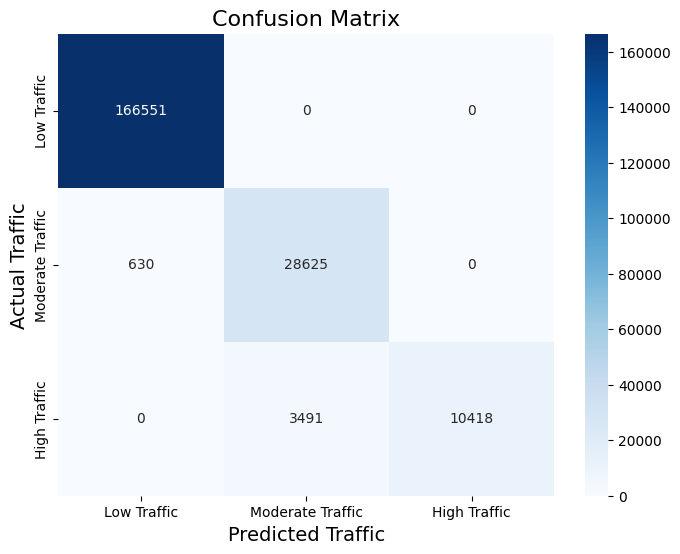

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
#Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Low Traffic", "Moderate Traffic", "High Traffic"], 
            yticklabels=["Low Traffic", "Moderate Traffic", "High Traffic"])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Traffic', fontsize=14)
plt.ylabel('Actual Traffic', fontsize=14)
plt.show()

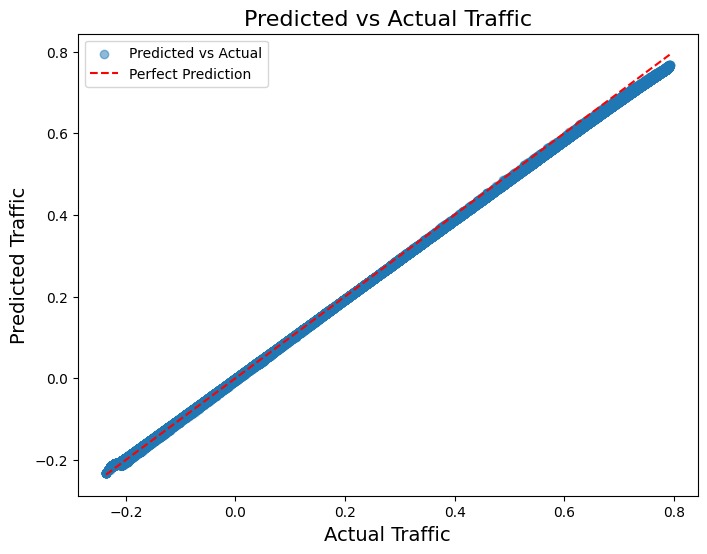

In [22]:
plt.figure(figsize=(8, 6))

# Scatter plot of predicted vs actual values
plt.scatter(y_test, predictions, alpha=0.5, label='Predicted vs Actual')

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')

# Add labels and title
plt.title('Predicted vs Actual Traffic', fontsize=16)
plt.xlabel('Actual Traffic', fontsize=14)
plt.ylabel('Predicted Traffic', fontsize=14)

# Add a legend
plt.legend()

# Show the plot
plt.show()

C:\Users\Monish\AppData\Local\Temp\ipykernel_2588\2138066928.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette='coolwarm')


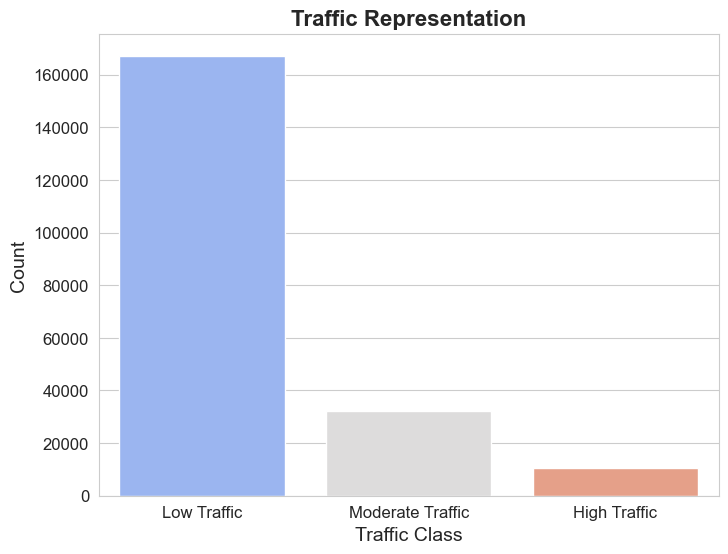

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Traffic classification
traffic_classes = [classify_traffic(pred[0]) for pred in predictions]
traffic_counts = pd.Series(traffic_classes).value_counts()

# Set figure size and style
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Improved color palette
sns.barplot(x=traffic_counts.index, y=traffic_counts.values, palette='coolwarm')

# Title and labels
plt.title('Traffic Representation', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Class', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display plot
plt.show()
